# RNN Capacity Sweep

В этом ноутбуке проверяем, является ли текущий `GRU h128` достаточной capacity для построения пользовательских embeddings, или качество можно улучшить увеличением hidden dimension / числа слоёв.

## План

1. Зафиксировать тот же user split и next-event protocol, что в `02`.
2. Сравнить несколько GRU-конфигураций вокруг текущего baseline.
3. Для каждой модели посчитать next-event metrics на `val/test`.
4. Для каждой модели построить prefix embeddings через `max pooling` и проверить downstream retention.
5. Выбрать, стоит ли усложнять основной RNN encoder.

## 1. Setup

In [1]:
from pathlib import Path
import sys
import json

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from src.data import EventWindowDataset, build_next_event_examples, load_prepared_sequences
from src.downstream import build_base_meta, build_baseline_features, build_meta_for_prefix, evaluate_xgboost_feature_set
from src.eval import evaluate_next_event_model_on_examples
from src.models import GRUEncoder, LSTMEncoder
from src.pooling import build_user_embeddings_with_pooling
from src.splits import apply_user_split, load_user_split
from src.train import choose_device, seed_everything, train_model

sns.set_theme(style='whitegrid')
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(20)


def to_pandas_safe(df: pl.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(df.to_dicts())


In [2]:
SEED = 42
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
DATA_DIR = ARTIFACTS_DIR / 'data'
RNN_DIR = ARTIFACTS_DIR / 'rnn'
OUT_DIR = ARTIFACTS_DIR / 'capacity_sweep'
CHECKPOINT_DIR = OUT_DIR / 'checkpoints'
EMBEDDINGS_DIR = OUT_DIR / 'embeddings'
FIGURES_DIR = OUT_DIR / 'figures'

for path in [OUT_DIR, CHECKPOINT_DIR, EMBEDDINGS_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PREPARED_DIR = DATA_DIR
SPLIT_PATH = DATA_DIR / 'split.json'
SPLIT_USERS_PATH = DATA_DIR / 'split_users.parquet'
CLEAN_EVENTS_GLOB = str(DATA_DIR / 'clean_events' / '*.parquet')

MAX_LEN = 128
STRIDE = 64
EVENT_DIM = 64
BATCH_SIZE = 128
EMBED_BATCH_SIZE = 512
EPOCHS = 5
LR = 1e-3
PREFIX_LEN = 150
TOP_K_EVENTS = 10
POOLING = 'max'
HORIZONS = {'retention_7d': 7, 'retention_14d': 14}
FORCE_RETRAIN = False

seed_everything(SEED)
device = choose_device()
device

device(type='mps')

## 2. Данные и сетка экспериментов

Используем тот же prepared dataset и тот же `master_split_lesha`, что в предыдущих ноутбуках. Сетка включает текущие reference-модели и четыре новых GRU-конфигурации: меньше capacity, больше hidden size, два слоя, и два слоя с большим hidden size.

In [3]:
prepared = load_prepared_sequences(PREPARED_DIR)
split = load_user_split(SPLIT_PATH)
split_prepared = apply_user_split(prepared, split)
train_prepared = split_prepared['train']
val_prepared = split_prepared['val']
test_prepared = split_prepared['test']
split_users = pl.read_parquet(SPLIT_USERS_PATH)

summary_df = pl.DataFrame(
    {
        'split': ['train', 'val', 'test'],
        'users': [len(train_prepared.user_ids), len(val_prepared.user_ids), len(test_prepared.user_ids)],
        'windows': [
            len(EventWindowDataset(train_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)),
            len(EventWindowDataset(val_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)),
            len(EventWindowDataset(test_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)),
        ],
    }
)
summary_df

split,users,windows
str,i64,i64
"""train""",36760,584936
"""val""",7896,129068
"""test""",7839,133885


In [4]:
capacity_configs = [
    {
        'experiment_id': 'gru_h64_l1',
        'model_type': 'gru',
        'hidden_dim': 64,
        'num_layers': 1,
        'dropout': 0.0,
        'source': 'train',
    },
    {
        'experiment_id': 'gru_h128_l1_ref',
        'model_type': 'gru',
        'hidden_dim': 128,
        'num_layers': 1,
        'dropout': 0.0,
        'source': 'reference',
        'checkpoint_path': RNN_DIR / 'rnn_encoder.pt',
    },
    {
        'experiment_id': 'gru_h256_l1',
        'model_type': 'gru',
        'hidden_dim': 256,
        'num_layers': 1,
        'dropout': 0.0,
        'source': 'train',
    },
    {
        'experiment_id': 'gru_h128_l2_d02',
        'model_type': 'gru',
        'hidden_dim': 128,
        'num_layers': 2,
        'dropout': 0.2,
        'source': 'train',
    },
    {
        'experiment_id': 'gru_h256_l2_d02',
        'model_type': 'gru',
        'hidden_dim': 256,
        'num_layers': 2,
        'dropout': 0.2,
        'source': 'train',
    },
    {
        'experiment_id': 'lstm_h128_l1_ref',
        'model_type': 'lstm',
        'hidden_dim': 128,
        'num_layers': 1,
        'dropout': 0.0,
        'source': 'reference',
        'checkpoint_path': RNN_DIR / 'lstm_encoder.pt',
    },
]

config_df = pl.DataFrame(
    [
        {
            'experiment_id': item['experiment_id'],
            'model_type': item['model_type'],
            'hidden_dim': item['hidden_dim'],
            'num_layers': item['num_layers'],
            'dropout': item['dropout'],
            'source': item['source'],
        }
        for item in capacity_configs
    ]
)
config_df.write_csv(OUT_DIR / 'capacity_config.csv')
config_df

experiment_id,model_type,hidden_dim,num_layers,dropout,source
str,str,i64,i64,f64,str
"""gru_h64_l1""","""gru""",64,1,0.0,"""train"""
"""gru_h128_l1_ref""","""gru""",128,1,0.0,"""reference"""
"""gru_h256_l1""","""gru""",256,1,0.0,"""train"""
"""gru_h128_l2_d02""","""gru""",128,2,0.2,"""train"""
"""gru_h256_l2_d02""","""gru""",256,2,0.2,"""train"""
"""lstm_h128_l1_ref""","""lstm""",128,1,0.0,"""reference"""


### Вывод по сетке

Сетка отделяет вопрос architecture capacity от вопроса pooling: downstream ниже везде использует один и тот же `max pooling`, потому что в `05` он оказался основным вариантом. Reference-строки нужны, чтобы не переобучать уже зафиксированные `GRU h128` и `LSTM h128`.

## 3. Next-event обучение и оценка

In [5]:
train_dataset = EventWindowDataset(train_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)
val_dataset = EventWindowDataset(val_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)
test_dataset = EventWindowDataset(test_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_examples = build_next_event_examples(val_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)
test_examples = build_next_event_examples(test_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)

def make_model(config):
    model_cls = GRUEncoder if config['model_type'] == 'gru' else LSTMEncoder
    return model_cls(
        vocab_size=len(prepared.event2idx),
        event_dim=EVENT_DIM,
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        dropout=config['dropout'],
    )

def load_checkpoint(model, checkpoint_path):
    payload = torch.load(checkpoint_path, map_location=device)
    state_dict = payload.get('model_state_dict', payload)
    model.load_state_dict(state_dict)
    return model

trained_models = {}
history_rows = []
metric_rows = []

for config in capacity_configs:
    experiment_id = config['experiment_id']
    checkpoint_path = Path(config.get('checkpoint_path', CHECKPOINT_DIR / f'{experiment_id}.pt'))
    print(f'=== {experiment_id} ===')
    seed_everything(SEED)
    model = make_model(config).to(device)

    if config['source'] == 'reference':
        model = load_checkpoint(model, checkpoint_path).to(device)
        history_rows.append({'experiment_id': experiment_id, 'epoch': 0, 'train_loss': None, 'source': 'reference'})
    elif checkpoint_path.exists() and not FORCE_RETRAIN:
        model = load_checkpoint(model, checkpoint_path).to(device)
        history_rows.append({'experiment_id': experiment_id, 'epoch': 0, 'train_loss': None, 'source': 'cached'})
    else:
        history = train_model(model, train_loader, device=device, epochs=EPOCHS, lr=LR)
        for epoch, loss_value in enumerate(history, start=1):
            history_rows.append({'experiment_id': experiment_id, 'epoch': epoch, 'train_loss': loss_value, 'source': 'train'})
        torch.save({'config': config, 'model_state_dict': model.state_dict()}, checkpoint_path)

    trained_models[experiment_id] = model

    for split_name, examples in [('val', val_examples), ('test', test_examples)]:
        metrics = evaluate_next_event_model_on_examples(model, examples, device=device, ks=(1, 5, 10))
        metric_rows.append(
            {
                'experiment_id': experiment_id,
                'model_type': config['model_type'],
                'hidden_dim': config['hidden_dim'],
                'num_layers': config['num_layers'],
                'dropout': config['dropout'],
                'split': split_name,
                **metrics,
            }
        )
        print(split_name, metrics)

history_df = pl.DataFrame(history_rows)
next_event_metrics_df = pl.DataFrame(metric_rows)
history_df.write_csv(OUT_DIR / 'capacity_training_history.csv')
next_event_metrics_df.write_csv(OUT_DIR / 'capacity_next_event_metrics.csv')
next_event_metrics_df

=== gru_h64_l1 ===


val {'loss': 0.6675919062067838, 'mrr': 0.8783636124431764, 'hit@1': 0.803297486160266, 'hit@5': 0.9690628199019172, 'hit@10': 0.9909582546983339, 'recall@1': 0.803297486160266, 'recall@5': 0.9690628199019172, 'recall@10': 0.9909582546983339}


test {'loss': 0.6407924644215244, 'mrr': 0.8840174914684076, 'hit@1': 0.8128169693120383, 'hit@5': 0.97016095942422, 'hit@10': 0.991141652010258, 'recall@1': 0.8128169693120383, 'recall@5': 0.97016095942422, 'recall@10': 0.991141652010258}
=== gru_h128_l1_ref ===


val {'loss': 0.6368636568049921, 'mrr': 0.8831636661890919, 'hit@1': 0.8098909100368409, 'hit@5': 0.9722394394867923, 'hit@10': 0.9923528684919389, 'recall@1': 0.8098909100368409, 'recall@5': 0.9722394394867923, 'recall@10': 0.9923528684919389}


test {'loss': 0.6120574092283568, 'mrr': 0.888496788448156, 'hit@1': 0.8185681741477243, 'hit@5': 0.9732830413368964, 'hit@10': 0.9925607797202632, 'recall@1': 0.8185681741477243, 'recall@5': 0.9732830413368964, 'recall@10': 0.9925607797202632}
=== gru_h256_l1 ===


...

val {'loss': 0.6078883895580831, 'mrr': 0.887403257027932, 'hit@1': 0.8153376517476275, 'hit@5': 0.9752611030458529, 'hit@10': 0.9937552294448292, 'recall@1': 0.8153376517476275, 'recall@5': 0.9752611030458529, 'recall@10': 0.9937552294448292}


test {'loss': 0.5856075373909341, 'mrr': 0.892522287494764, 'hit@1': 0.824177466228793, 'hit@5': 0.9760466068276334, 'hit@10': 0.9937782430740514, 'recall@1': 0.824177466228793, 'recall@5': 0.9760466068276334, 'recall@10': 0.9937782430740514}
=== lstm_h128_l1_ref ===


val {'loss': 0.6378986977513428, 'mrr': 0.8827839391562635, 'hit@1': 0.8092400906020724, 'hit@5': 0.9721697090903602, 'hit@10': 0.9922211543836211, 'recall@1': 0.8092400906020724, 'recall@5': 0.9721697090903602, 'recall@10': 0.9922211543836211}


test {'loss': 0.6118466518081703, 'mrr': 0.8886104377273146, 'hit@1': 0.8189266903541903, 'hit@5': 0.9732307583475396, 'hit@10': 0.9926578779762292, 'recall@1': 0.8189266903541903, 'recall@5': 0.9732307583475396, 'recall@10': 0.9926578779762292}


experiment_id,model_type,hidden_dim,num_layers,dropout,split,loss,mrr,hit@1,hit@5,hit@10,recall@1,recall@5,recall@10
str,str,i64,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64
"""gru_h64_l1""","""gru""",64,1,0.0,"""val""",0.667592,0.878364,0.803297,0.969063,0.990958,0.803297,0.969063,0.990958
"""gru_h64_l1""","""gru""",64,1,0.0,"""test""",0.640792,0.884017,0.812817,0.970161,0.991142,0.812817,0.970161,0.991142
"""gru_h128_l1_ref""","""gru""",128,1,0.0,"""val""",0.636864,0.883164,0.809891,0.972239,0.992353,0.809891,0.972239,0.992353
"""gru_h128_l1_ref""","""gru""",128,1,0.0,"""test""",0.612057,0.888497,0.818568,0.973283,0.992561,0.818568,0.973283,0.992561
"""gru_h256_l1""","""gru""",256,1,0.0,"""val""",0.617088,0.886301,0.814191,0.974246,0.992973,0.814191,0.974246,0.992973
"""gru_h256_l1""","""gru""",256,1,0.0,"""test""",0.592872,0.891704,0.823087,0.975053,0.993494,0.823087,0.975053,0.993494
"""gru_h128_l2_d02""","""gru""",128,2,0.2,"""val""",0.625638,0.885165,0.812572,0.973332,0.993081,0.812572,0.973332,0.993081
"""gru_h128_l2_d02""","""gru""",128,2,0.2,"""test""",0.60053,0.890398,0.821474,0.974187,0.993158,0.821474,0.974187,0.993158
"""gru_h256_l2_d02""","""gru""",256,2,0.2,"""val""",0.607888,0.887403,0.815338,0.975261,0.993755,0.815338,0.975261,0.993755


In [6]:
test_next_event_df = next_event_metrics_df.filter(pl.col('split') == 'test').sort('mrr', descending=True)
test_next_event_df.select(['experiment_id', 'model_type', 'hidden_dim', 'num_layers', 'dropout', 'loss', 'mrr', 'hit@5', 'hit@10'])

experiment_id,model_type,hidden_dim,num_layers,dropout,loss,mrr,hit@5,hit@10
str,str,i64,i64,f64,f64,f64,f64,f64
"""gru_h256_l2_d02""","""gru""",256,2,0.2,0.585608,0.892522,0.976047,0.993778
"""gru_h256_l1""","""gru""",256,1,0.0,0.592872,0.891704,0.975053,0.993494
"""gru_h128_l2_d02""","""gru""",128,2,0.2,0.60053,0.890398,0.974187,0.993158
"""lstm_h128_l1_ref""","""lstm""",128,1,0.0,0.611847,0.88861,0.973231,0.992658
"""gru_h128_l1_ref""","""gru""",128,1,0.0,0.612057,0.888497,0.973283,0.992561
"""gru_h64_l1""","""gru""",64,1,0.0,0.640792,0.884017,0.970161,0.991142


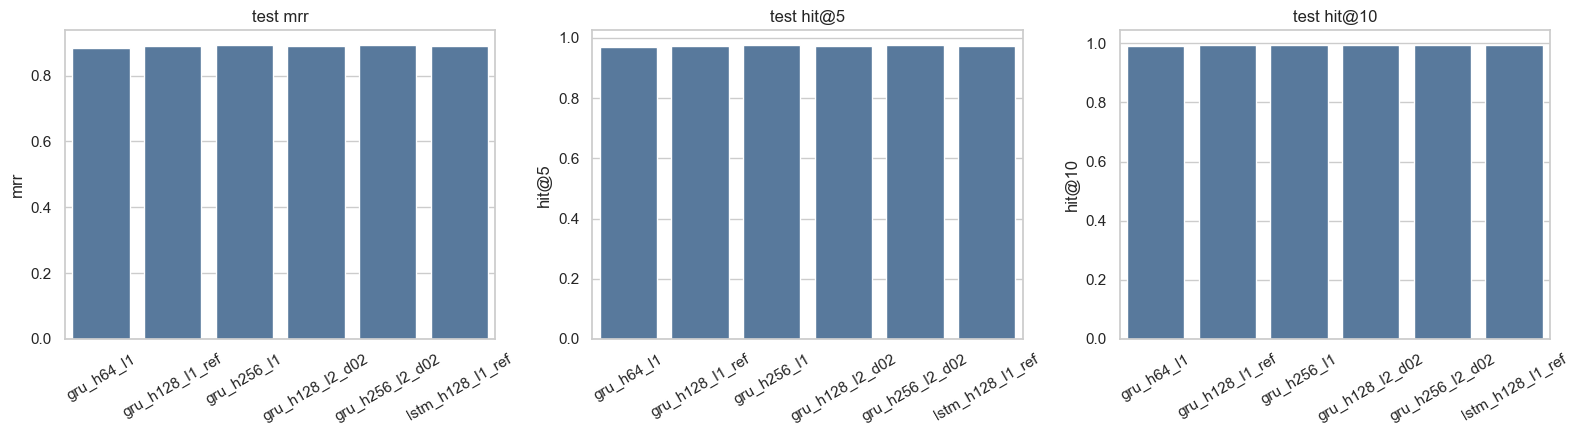

In [7]:
plot_pdf = to_pandas_safe(next_event_metrics_df.filter(pl.col('split') == 'test'))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric_name in zip(axes, ['mrr', 'hit@5', 'hit@10']):
    sns.barplot(data=plot_pdf, x='experiment_id', y=metric_name, ax=ax, color='#4C78A8')
    ax.set_title(f'test {metric_name}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'capacity_next_event_metrics.png', dpi=180)
plt.show()

### Вывод по next-event capacity

Capacity sweep использует тот же next-event evaluation protocol, что и `02`: для каждого окна модель получает prefix и предсказывает следующий event в конце окна. По этому протоколу увеличение capacity даёт устойчивый intrinsic-прирост: reference `GRU h128` имеет test MRR `0.8885` и Hit@10 `0.9926`, `GRU h256 l1` поднимается до `0.8917 / 0.9935`, а лучший `GRU h256 l2` — до `0.8925 / 0.9938`. Значит, базовый `GRU h128` не был полностью насыщен по sequence objective.

## 4. Downstream retention через max pooling

In [8]:
base_meta, data_end_ts = build_base_meta(CLEAN_EVENTS_GLOB, prepared.user_ids)
meta, label_summary_df = build_meta_for_prefix(base_meta, prefix_len=PREFIX_LEN, horizons=HORIZONS, data_end_ts=data_end_ts)
baseline_df, baseline_cols, baseline_summary_df = build_baseline_features(
    prepared,
    train_prepared,
    split_users,
    meta,
    prefix_len=PREFIX_LEN,
    top_k_events=TOP_K_EVENTS,
    horizons=HORIZONS,
)
label_summary_df.write_csv(OUT_DIR / 'capacity_label_summary.csv')
baseline_summary_df.write_csv(OUT_DIR / 'capacity_baseline_summary.csv')
label_summary_df

prefix_len,label,valid_users,positive_rate
i64,str,i64,f64
150,"""retention_7d""",18547,0.281124
150,"""retention_14d""",15207,0.181758


In [9]:
downstream_rows = []
embedding_summary_rows = []

for config in capacity_configs:
    experiment_id = config['experiment_id']
    model = trained_models[experiment_id]
    embeddings_path = EMBEDDINGS_DIR / f'{experiment_id}_{POOLING}_prefix{PREFIX_LEN}.parquet'
    print(f'building embeddings: {experiment_id}')

    if embeddings_path.exists() and not FORCE_RETRAIN:
        embeddings_df = pl.read_parquet(embeddings_path)
    else:
        embeddings_df = build_user_embeddings_with_pooling(
            model,
            prepared,
            max_len=PREFIX_LEN,
            batch_size=EMBED_BATCH_SIZE,
            device=device,
            pooling=POOLING,
            take_last=False,
        )
        embeddings_df.write_parquet(embeddings_path)

    embedding_cols = [col for col in embeddings_df.columns if col.startswith('emb_')]
    embedding_summary_rows.append(
        {
            'experiment_id': experiment_id,
            'pooling': POOLING,
            'num_embedding_features': len(embedding_cols),
            'num_users': embeddings_df.height,
        }
    )
    joined_df = baseline_df.join(embeddings_df, on='appmetrica_device_id', how='inner')

    for label_name in HORIZONS:
        emb_metrics = evaluate_xgboost_feature_set(
            joined_df,
            embedding_cols,
            label_name,
            f'{experiment_id} {POOLING}',
            seed=SEED,
        ).with_columns(
            pl.lit(experiment_id).alias('experiment_id'),
            pl.lit(config['model_type']).alias('model_type'),
            pl.lit(config['hidden_dim']).alias('hidden_dim'),
            pl.lit(config['num_layers']).alias('num_layers'),
            pl.lit(config['dropout']).alias('dropout'),
            pl.lit(POOLING).alias('pooling'),
            pl.lit('embedding').alias('feature_group'),
            pl.lit(len(embedding_cols)).alias('num_features'),
        )
        combo_metrics = evaluate_xgboost_feature_set(
            joined_df,
            [*baseline_cols, *embedding_cols],
            label_name,
            f'Baseline + {experiment_id} {POOLING}',
            seed=SEED,
        ).with_columns(
            pl.lit(experiment_id).alias('experiment_id'),
            pl.lit(config['model_type']).alias('model_type'),
            pl.lit(config['hidden_dim']).alias('hidden_dim'),
            pl.lit(config['num_layers']).alias('num_layers'),
            pl.lit(config['dropout']).alias('dropout'),
            pl.lit(POOLING).alias('pooling'),
            pl.lit('baseline_plus_embedding').alias('feature_group'),
            pl.lit(len(baseline_cols) + len(embedding_cols)).alias('num_features'),
        )
        downstream_rows.extend([emb_metrics, combo_metrics])

capacity_downstream_metrics_df = pl.concat(downstream_rows, how='vertical_relaxed')
embedding_summary_df = pl.DataFrame(embedding_summary_rows)
capacity_downstream_metrics_df.write_csv(OUT_DIR / 'capacity_downstream_metrics.csv')
embedding_summary_df.write_csv(OUT_DIR / 'capacity_embedding_summary.csv')
capacity_downstream_metrics_df

building embeddings: gru_h64_l1


building embeddings: gru_h128_l1_ref


building embeddings: gru_h256_l1


building embeddings: gru_h128_l2_d02


building embeddings: gru_h256_l2_d02


building embeddings: lstm_h128_l1_ref


feature_set,label,split,roc_auc,pr_auc,num_users,experiment_id,model_type,hidden_dim,num_layers,dropout,pooling,feature_group,num_features
str,str,str,f64,f64,i64,str,str,i32,i32,f64,str,str,i32
"""gru_h64_l1 max""","""retention_7d""","""val""",0.664783,0.470161,2783,"""gru_h64_l1""","""gru""",64,1,0.0,"""max""","""embedding""",64
"""gru_h64_l1 max""","""retention_7d""","""test""",0.685379,0.484113,2805,"""gru_h64_l1""","""gru""",64,1,0.0,"""max""","""embedding""",64
"""Baseline + gru_h64_l1 max""","""retention_7d""","""val""",0.657013,0.467874,2783,"""gru_h64_l1""","""gru""",64,1,0.0,"""max""","""baseline_plus_embedding""",79
"""Baseline + gru_h64_l1 max""","""retention_7d""","""test""",0.687964,0.477573,2805,"""gru_h64_l1""","""gru""",64,1,0.0,"""max""","""baseline_plus_embedding""",79
"""gru_h64_l1 max""","""retention_14d""","""val""",0.707321,0.361879,2318,"""gru_h64_l1""","""gru""",64,1,0.0,"""max""","""embedding""",64
"""gru_h64_l1 max""","""retention_14d""","""test""",0.690841,0.351186,2303,"""gru_h64_l1""","""gru""",64,1,0.0,"""max""","""embedding""",64
"""Baseline + gru_h64_l1 max""","""retention_14d""","""val""",0.709838,0.36886,2318,"""gru_h64_l1""","""gru""",64,1,0.0,"""max""","""baseline_plus_embedding""",79
"""Baseline + gru_h64_l1 max""","""retention_14d""","""test""",0.694709,0.356713,2303,"""gru_h64_l1""","""gru""",64,1,0.0,"""max""","""baseline_plus_embedding""",79
"""gru_h128_l1_ref max""","""retention_7d""","""val""",0.660647,0.475461,2783,"""gru_h128_l1_ref""","""gru""",128,1,0.0,"""max""","""embedding""",128


In [10]:
test_downstream_df = capacity_downstream_metrics_df.filter(pl.col('split') == 'test')
best_downstream_df = (
    test_downstream_df
    .sort(['label', 'feature_group', 'roc_auc'], descending=[False, False, True])
    .group_by(['label', 'feature_group'], maintain_order=True)
    .head(3)
)
best_downstream_df.select(
    ['label', 'feature_group', 'experiment_id', 'model_type', 'hidden_dim', 'num_layers', 'dropout', 'roc_auc', 'pr_auc', 'num_users']
)

label,feature_group,experiment_id,model_type,hidden_dim,num_layers,dropout,roc_auc,pr_auc,num_users
str,str,str,str,i32,i32,f64,f64,f64,i64
"""retention_14d""","""baseline_plus_embedding""","""gru_h256_l1""","""gru""",256,1,0.0,0.710023,0.366211,2303
"""retention_14d""","""baseline_plus_embedding""","""lstm_h128_l1_ref""","""lstm""",128,1,0.0,0.69802,0.361031,2303
"""retention_14d""","""baseline_plus_embedding""","""gru_h128_l1_ref""","""gru""",128,1,0.0,0.695017,0.36031,2303
"""retention_14d""","""embedding""","""gru_h256_l1""","""gru""",256,1,0.0,0.704364,0.358962,2303
"""retention_14d""","""embedding""","""lstm_h128_l1_ref""","""lstm""",128,1,0.0,0.697199,0.360282,2303
"""retention_14d""","""embedding""","""gru_h128_l2_d02""","""gru""",128,2,0.2,0.694739,0.372302,2303
"""retention_7d""","""baseline_plus_embedding""","""lstm_h128_l1_ref""","""lstm""",128,1,0.0,0.690864,0.487689,2805
"""retention_7d""","""baseline_plus_embedding""","""gru_h256_l1""","""gru""",256,1,0.0,0.688496,0.494573,2805
"""retention_7d""","""baseline_plus_embedding""","""gru_h64_l1""","""gru""",64,1,0.0,0.687964,0.477573,2805


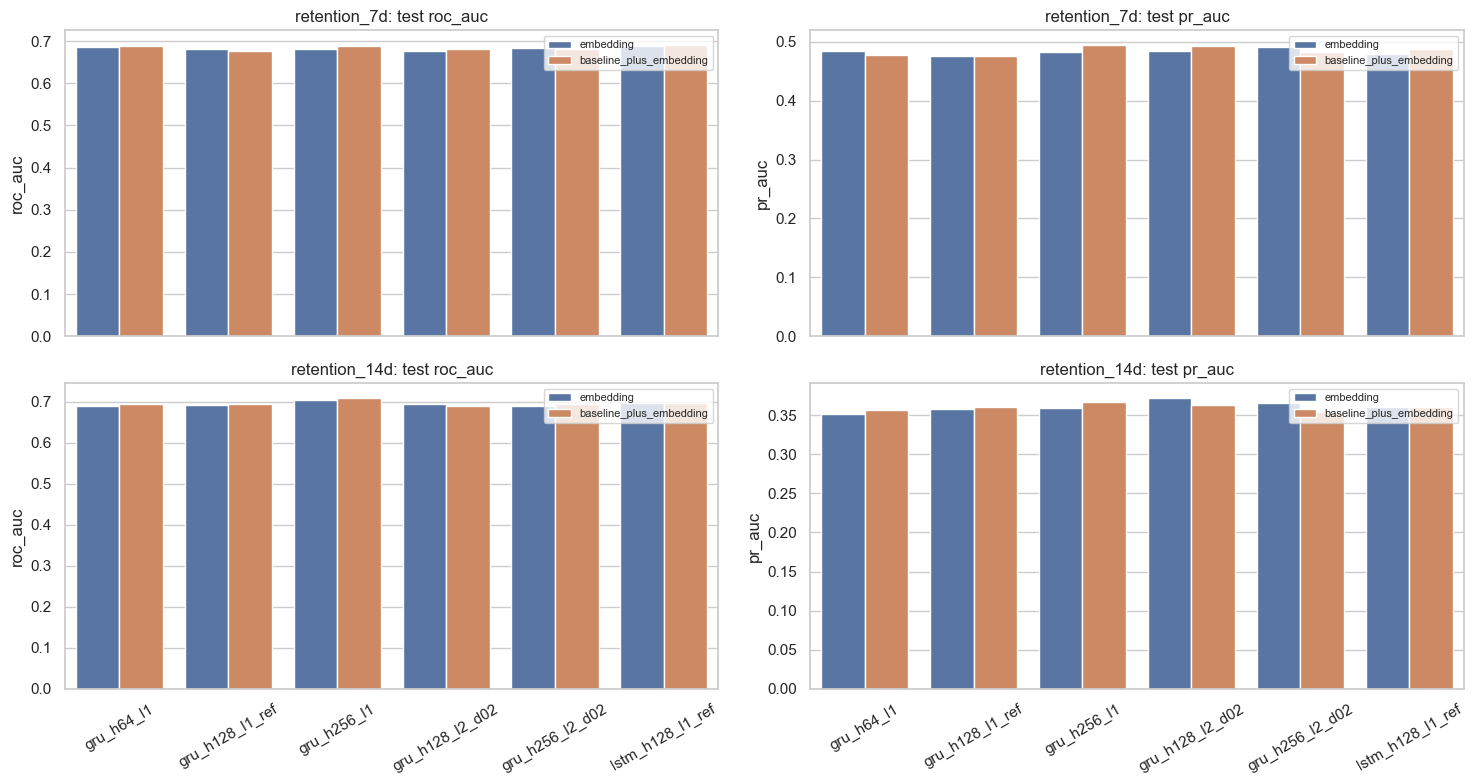

In [11]:
plot_pdf = to_pandas_safe(test_downstream_df)
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
for row_idx, label_name in enumerate(['retention_7d', 'retention_14d']):
    for col_idx, metric_name in enumerate(['roc_auc', 'pr_auc']):
        ax = axes[row_idx, col_idx]
        subset = plot_pdf[plot_pdf['label'] == label_name]
        sns.barplot(data=subset, x='experiment_id', y=metric_name, hue='feature_group', ax=ax)
        ax.set_title(f'{label_name}: test {metric_name}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)
        ax.legend(fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'capacity_downstream_metrics.png', dpi=180)
plt.show()

### Вывод по downstream capacity

Downstream не повторяет next-event ranking. Лучший по next-event `GRU h256 l2` не становится лучшим retention embedding. Для `retention_14d` максимальный ROC-AUC даёт `GRU h256 l1 max + baseline` (`0.7100`), а чистый `GRU h256 l1 max` даёт `0.7044`. Для `retention_7d` single-run ROC-AUC чуть выше у `LSTM h128 max + baseline` (`0.6909`), но `GRU h256 l1 max + baseline` близок по ROC-AUC (`0.6885`) и лучше по PR-AUC (`0.4946`). Поэтому capacity помогает, но лучший sequence encoder и лучший user embedding — не одно и то же.

## 5. Итоговая таблица

In [12]:
next_event_test = next_event_metrics_df.filter(pl.col('split') == 'test').select(
    ['experiment_id', 'loss', 'mrr', 'hit@5', 'hit@10']
)
retention_pivot = (
    test_downstream_df
    .select(['experiment_id', 'feature_group', 'label', 'roc_auc', 'pr_auc'])
    .with_columns((pl.col('label') + '_' + pl.col('feature_group')).alias('task'))
    .select(['experiment_id', 'task', 'roc_auc', 'pr_auc'])
    .pivot(index='experiment_id', on='task', values=['roc_auc', 'pr_auc'])
)
final_table_df = config_df.join(next_event_test, on='experiment_id', how='left').join(retention_pivot, on='experiment_id', how='left')
final_table_df.write_csv(OUT_DIR / 'capacity_final_table.csv')
final_table_df

experiment_id,model_type,hidden_dim,num_layers,dropout,source,loss,mrr,hit@5,hit@10,roc_auc_retention_7d_embedding,roc_auc_retention_7d_baseline_plus_embedding,roc_auc_retention_14d_embedding,roc_auc_retention_14d_baseline_plus_embedding,pr_auc_retention_7d_embedding,pr_auc_retention_7d_baseline_plus_embedding,pr_auc_retention_14d_embedding,pr_auc_retention_14d_baseline_plus_embedding
str,str,i64,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""gru_h64_l1""","""gru""",64,1,0.0,"""train""",0.640792,0.884017,0.970161,0.991142,0.685379,0.687964,0.690841,0.694709,0.484113,0.477573,0.351186,0.356713
"""gru_h128_l1_ref""","""gru""",128,1,0.0,"""reference""",0.612057,0.888497,0.973283,0.992561,0.681441,0.677406,0.691212,0.695017,0.475861,0.476001,0.357899,0.36031
"""gru_h256_l1""","""gru""",256,1,0.0,"""train""",0.592872,0.891704,0.975053,0.993494,0.680879,0.688496,0.704364,0.710023,0.482494,0.494573,0.358962,0.366211
"""gru_h128_l2_d02""","""gru""",128,2,0.2,"""train""",0.60053,0.890398,0.974187,0.993158,0.67634,0.682454,0.694739,0.689087,0.484137,0.493074,0.372302,0.362605
"""gru_h256_l2_d02""","""gru""",256,2,0.2,"""train""",0.585608,0.892522,0.976047,0.993778,0.684072,0.681264,0.690483,0.694338,0.49109,0.482385,0.365783,0.354468
"""lstm_h128_l1_ref""","""lstm""",128,1,0.0,"""reference""",0.611847,0.88861,0.973231,0.992658,0.688527,0.690864,0.697199,0.69802,0.479472,0.487689,0.360282,0.361031


In [13]:
next_best = next_event_metrics_df.filter(pl.col('split') == 'test').sort('mrr', descending=True).row(0, named=True)
retention_best = test_downstream_df.sort('roc_auc', descending=True).group_by('label', maintain_order=True).head(1)
print('best_next_event_by_mrr:', next_best)
print(retention_best.select(['label', 'feature_group', 'experiment_id', 'roc_auc', 'pr_auc']))

best_next_event_by_mrr: {'experiment_id': 'gru_h256_l2_d02', 'model_type': 'gru', 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.2, 'split': 'test', 'loss': 0.5856075373909341, 'mrr': 0.892522287494764, 'hit@1': 0.824177466228793, 'hit@5': 0.9760466068276334, 'hit@10': 0.9937782430740514, 'recall@1': 0.824177466228793, 'recall@5': 0.9760466068276334, 'recall@10': 0.9937782430740514}
shape: (2, 5)
┌───────────────┬─────────────────────────┬──────────────────┬──────────┬──────────┐
│ label         ┆ feature_group           ┆ experiment_id    ┆ roc_auc  ┆ pr_auc   │
│ ---           ┆ ---                     ┆ ---              ┆ ---      ┆ ---      │
│ str           ┆ str                     ┆ str              ┆ f64      ┆ f64      │
╞═══════════════╪═════════════════════════╪══════════════════╪══════════╪══════════╡
│ retention_14d ┆ baseline_plus_embedding ┆ gru_h256_l1      ┆ 0.710023 ┆ 0.366211 │
│ retention_7d  ┆ baseline_plus_embedding ┆ lstm_h128_l1_ref ┆ 0.690864 ┆ 0.487689 │
└──

## Итог

Capacity sweep показал, что увеличение ёмкости действительно улучшает next-event prediction, но этот выигрыш не переносится в retention один-в-один.

По next-event лучший результат у `GRU h256, 2 layers, dropout=0.2`: test MRR `0.8925`, Hit@5 `0.9760`, Hit@10 `0.9938`. Это выше reference `GRU h128` (`0.8885 / 0.9733 / 0.9926`) и `LSTM h128` (`0.8886 / 0.9732 / 0.9927`) из `02`. Значит, базовый encoder не был полностью насыщен по sequence objective.

В downstream картина другая. На `retention_14d` лучший результат даёт `GRU h256, 1 layer` с `Baseline + embedding`: ROC-AUC `0.7100`, PR-AUC `0.3662`. Это сильнее предыдущего основного `GRU h128 max` и лучше, чем более глубокий `GRU h256, 2 layers`, который выигрывает next-event, но проседает в retention. На `retention_7d` лучший ROC-AUC у `LSTM h128 + baseline` (`0.6909`), а лучший PR-AUC среди сильных вариантов у `GRU h256, 1 layer + baseline` (`0.4946`).

Практический вывод: если выбирать один RNN-кандидат для финального сравнения, самым разумным вариантом становится `GRU h256, 1 layer + max pooling`. Он заметно улучшает `retention_14d`, остаётся сильным на `retention_7d`, проще и стабильнее интерпретируется, чем двухслойный `GRU h256`. Двухслойная модель полезна как результат про capacity: она лучше учит next-event, но не является лучшим user embedding для retention.

Следующий шаг после этого ноутбука — seed stability для финальных кандидатов: `GRU h128 max`, `GRU h256_l1 max`, `GRU h256_l2 max` и `LSTM h128 max`. Эта проверка выполнена в `11_final_stability` и подтверждает выбор `GRU h256, 1 layer + max pooling` как основного RNN-варианта.